# Creating Gradient Boosting Model.

- This is the Gradient Boosting model to Detect **is_patent** haveing **thyroid** or Not.
- Also comparing this Gradient Boosint Model with the Other Algorith like [Random Forest, Support Vector Machine (SVM)] Model to Check which model is Suital for this Function.

In [2]:
# Importing all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
# Loading the DataSet
data_frame = pd.read_csv("DataSet/Thyrade_Data.csv")

In [4]:
# Printing the first 5 rows of the Data
data_frame.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender,Label
0,0.152057,83.548344,2.177021,188.856216,2826.029764,F,1
1,0.167795,84.339802,3.275490,186.948273,2904.068090,F,1
2,0.162089,85.018738,2.974651,140.008652,2975.807721,F,1
3,0.165153,86.267416,3.139661,141.112412,3009.854705,F,1
4,0.150852,85.568045,3.174957,150.523972,3002.041866,F,1


In [5]:
# Data preprocessing
# Checking for missing values
data_frame.isnull().sum()

Volume (RMS)    0
Pitch (F0)      0
Jitter          0
Hoarseness      0
Fatigue         0
Gender          0
Label           0
dtype: int64

In [6]:
# Checking for duplicates
data_frame.duplicated().sum()

np.int64(0)

In [7]:
# Spliting the dataset into features and target variable
X = data_frame.iloc[:, :-1]  # Features
y = data_frame.iloc[:, -1]   # Target variable

In [8]:
# Checking the first 5 rows of the features
X.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
0,0.152057,83.548344,2.177021,188.856216,2826.029764,F
1,0.167795,84.339802,3.275490,186.948273,2904.068090,F
2,0.162089,85.018738,2.974651,140.008652,2975.807721,F
3,0.165153,86.267416,3.139661,141.112412,3009.854705,F
4,0.150852,85.568045,3.174957,150.523972,3002.041866,F


In [9]:
# Checking the first 5 rows of the target variable
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64

In [10]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40, 6), (10, 6), (40,), (10,))

In [12]:
X_test.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
13,0.128334,85.054797,4.266133,25.535313,3273.960809,M
39,0.064983,81.137651,1.695055,195.582840,1730.787239,F
30,0.126373,84.025670,3.913280,126.342491,2303.514090,F
45,0.157419,83.187176,2.602660,12.670400,1888.624570,M
17,0.109277,87.053092,3.128937,20.175222,3351.969890,F


In [13]:
# Tansforming the Gender column using LabelEncoder
le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

In [14]:
X_test.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
13,0.128334,85.054797,4.266133,25.535313,3273.960809,1
39,0.064983,81.137651,1.695055,195.582840,1730.787239,0
30,0.126373,84.025670,3.913280,126.342491,2303.514090,0
45,0.157419,83.187176,2.602660,12.670400,1888.624570,1
17,0.109277,87.053092,3.128937,20.175222,3351.969890,0


In [15]:
X_train.head()

,Volume (RMS),Pitch (F0),Jitter,Hoarseness,Fatigue,Gender
12,0.112476,84.797199,3.268684,24.605160,3186.397126,1
4,0.150852,85.568045,3.174957,150.523972,3002.041866,0
37,0.076192,82.212478,1.885303,76.693726,1621.423594,0
8,0.149640,87.967701,4.855564,174.910507,3556.173315,0
3,0.165153,86.267416,3.139661,141.112412,3009.854705,0


In [17]:
#  Creating a pipeline for scaling and modeling
model = Pipeline([
    ('scaler', StandardScaler()),
    ('Gradient_Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3))
])

In [18]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('Gradient_Boosting',
                 GradientBoostingClassifier(random_state=42))])

In [19]:
# Predicting the target variable for the test set
y_pred = model.predict(X_test)

In [20]:
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 1])

In [21]:
y_test

13    1
39    0
30    0
45    0
17    1
48    0
26    0
25    0
32    0
19    1
Name: Label, dtype: int64

In [22]:
# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix:\n", confusion)

Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1 Score:  1.0
ROC AUC Score:  1.0
Confusion Matrix:
 [[7 0]
 [0 3]]


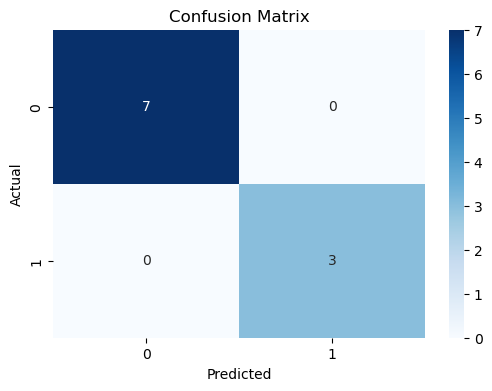

In [23]:
# Visualizing the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()